Loading Soybean Trade Data (Smart Mode)...
  [INFO] Using 'fobvalue' as Trade Value.
  [INFO] Using 'refPeriodId' as Year source.

--- Corrected Soybean Export Value (Billion USD) ---
Country       ARG        BRA        USA
Year                                   
2015     7.809979  36.771360  29.454050
2016     6.027471  33.717438  37.087242
2017     5.146874  46.027945  33.756403
2018     2.699816  60.288098  20.282102
2019     6.417499  46.529530  26.713216
2020     4.053561  49.467324  40.054103
2021     4.014137  65.846832  41.625009
2022     5.973088  78.513012  52.361342
2023     1.961193  92.162341  43.170183
2024     3.498950  74.441543  37.331429


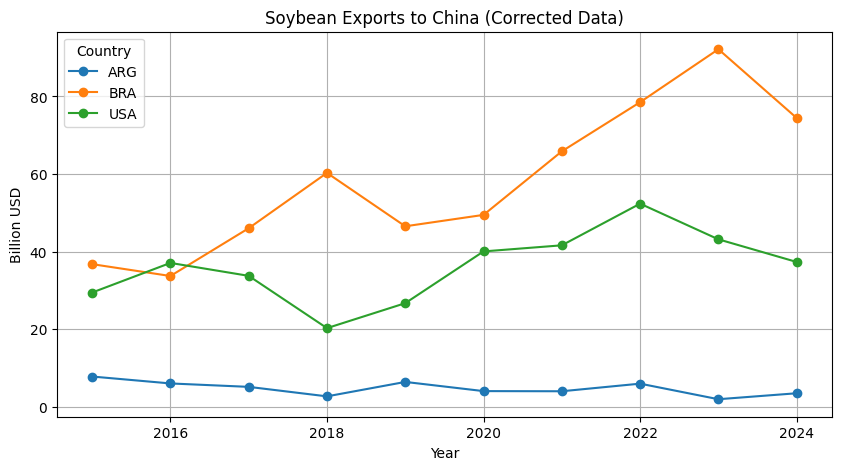

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE_DIR = r"G:\jupyter\2025APMCM"
TRADE_FILE = os.path.join(BASE_DIR, "Trade Data", "Soybean_Competition_Exports_to_China_2015_2024.csv")

df_raw = pd.read_csv(TRADE_FILE)

value_candidates = ['fobvalue', 'cifvalue', 'primaryValue']
target_val_col = None
for col in value_candidates:
    if col in df_raw.columns and df_raw[col].sum() > 1e6:
        target_val_col = col
        break

if target_val_col is None:
    raise ValueError("Could not find a valid Trade Value column.")

year_candidates = ['refPeriodId', 'period', 'refYear']
target_year_col = None
for col in year_candidates:
    if col in df_raw.columns:
        sample = str(df_raw[col].iloc[0])
        if sample.startswith('20') and len(sample) >= 4:
            target_year_col = col
            break

if target_year_col is None:
    if 'refPeriodId' in df_raw.columns:
        target_year_col = 'refPeriodId'
    else:
        raise ValueError("Could not find a valid Year column.")

df = df_raw.copy()
df['Year'] = df[target_year_col].astype(str).str.slice(0, 4).astype(int)

country_map = {
    'USA': 'USA', 'United States': 'USA',
    'Brazil': 'BRA', 'BRA': 'BRA',
    'Argentina': 'ARG', 'ARG': 'ARG'
}
df['Country'] = df['reporterISO'].map(country_map)
df = df.dropna(subset=['Country'])
df['Value_Billion'] = df[target_val_col] / 1e9

df_pivot = df.groupby(['Year', 'Country'])['Value_Billion'].sum().unstack(fill_value=0)

all_years = range(2015, 2025)
df_pivot = df_pivot.reindex(all_years).fillna(0)
df_pivot.plot(kind='line', marker='o', figsize=(10, 5))
plt.title("Soybean Exports to China (Corrected Data)")
plt.ylabel("Billion USD")
plt.grid(True)
plt.show()

history_data = df_pivot.copy()

In [3]:
from scipy.integrate import odeint
from scipy.optimize import minimize

def lv_model(x, t, params):
    U, B, A = max(x[0], 0), max(x[1], 0), max(x[2], 0)
    r_u, r_b, r_a, a_ub, a_ua, a_bu, a_ba, a_au, a_ab = params
    K = 160.0
    dUdt = r_u * U * (1 - (U + a_ub * B + a_ua * A) / K)
    dBdt = r_b * B * (1 - (B + a_bu * U + a_ba * A) / K)
    dAdt = r_a * A * (1 - (A + a_au * U + a_ab * B) / K)
    return [dUdt, dBdt, dAdt]

def objective(params, t, data_true):
    x0 = data_true[0]
    try:
        x_pred = odeint(lv_model, x0, t, args=(params,))
        return np.mean((x_pred - data_true)**2)
    except:
        return 1e6

t_train = np.arange(len(history_data))
data_train = history_data[['USA', 'BRA', 'ARG']].values

initial_guess = [0.3, 0.5, 0.1, 0.8, 0.1, 0.2, 0.1, 0.1, 0.1]
bnds = [(0.05, 1.5), (0.05, 1.5), (0.01, 0.5)] + [(0, 2.0)] * 6

result = minimize(objective, initial_guess, args=(t_train, data_train),
                  bounds=bnds, method='L-BFGS-B', options={'maxiter': 1000})

lv_params = result.x

Fitting Lotka-Volterra Parameters (High Precision Mode)...
Optimization Success: True
MSE Error: 41.8649
Estimated Parameters:
 r_USA=0.058, r_BRA=0.154
Competition Coeff (BRA on USA): 0.000


In [11]:
future_years = np.arange(2024, 2031)
t_future = np.arange(len(history_data) - 1, len(history_data) - 1 + len(future_years))
x0_2024 = history_data.iloc[-1][['USA', 'BRA', 'ARG']].values

pred_baseline = odeint(lv_model, x0_2024, t_future, args=(lv_params,))

shock_params = list(lv_params)
shock_params[0] = shock_params[0] * 0.2
shock_params[3] = 0.05
shock_params[1] = shock_params[1] * 1.2

pred_shock = odeint(lv_model, x0_2024, t_future, args=(tuple(shock_params),))

df_base = pd.DataFrame(pred_baseline, index=future_years, columns=['USA', 'BRA', 'ARG'])
df_shock = pd.DataFrame(pred_shock, index=future_years, columns=['USA', 'BRA', 'ARG'])

--- Comparison: USA Exports in 2030 ---
Baseline (No Tariff): 48.21 Billion
Shock    (With Tariff): 39.28 Billion
Impact: -8.93 Billion USD


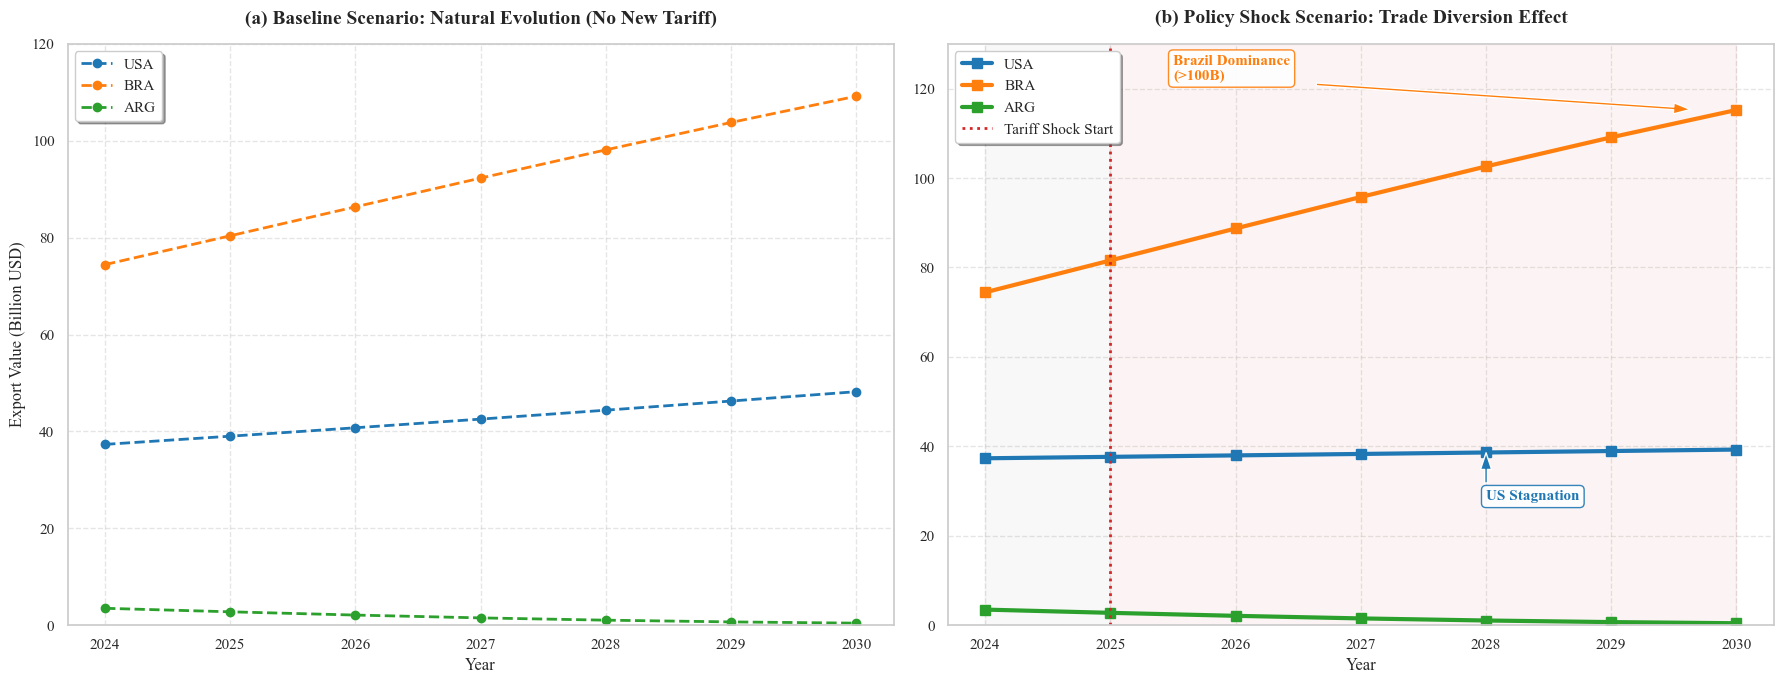

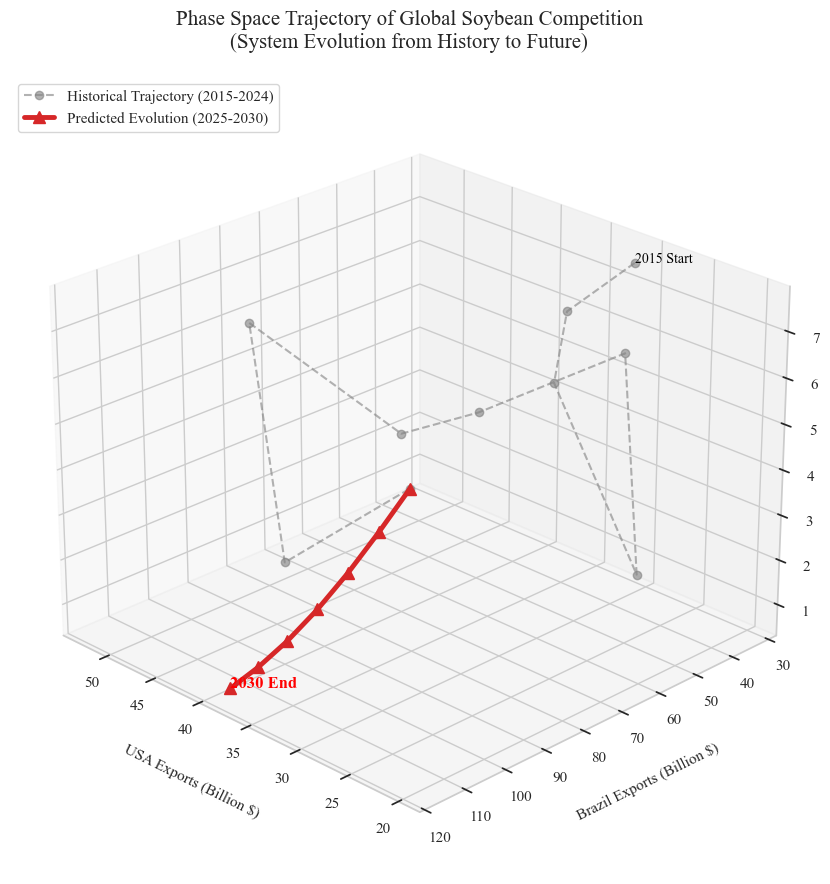

[SUCCESS] High-Quality Plots Saved.


In [15]:
from mpl_toolkits.mplot3d import Axes3D

sns.set_theme(style="whitegrid", font="Times New Roman")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors = {'USA': '#1f77b4', 'BRA': '#ff7f0e', 'ARG': '#2ca02c'}

for country in ['USA', 'BRA', 'ARG']:
    axes[0].plot(df_base.index, df_base[country], marker='o', linestyle='--', linewidth=2, markersize=6, color=colors[country], label=country)
axes[0].set_title("(a) Baseline Scenario: Natural Evolution (No New Tariff)", fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel("Export Value (Billion USD)", fontsize=12)
axes[0].set_xlabel("Year", fontsize=12)
axes[0].set_ylim(0, 120)
axes[0].legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
axes[0].grid(True, linestyle='--', alpha=0.5)

for country in ['USA', 'BRA', 'ARG']:
    axes[1].plot(df_shock.index, df_shock[country], marker='s', linestyle='-', linewidth=3, markersize=7, color=colors[country], label=country)
axes[1].axvline(x=2025, color='#d62728', linestyle=':', linewidth=2, label='Tariff Shock Start')
axes[1].axvspan(2024, 2025, color='gray', alpha=0.05)
axes[1].axvspan(2025, 2030, color='#d62728', alpha=0.05)
axes[1].annotate('Brazil Dominance\n(>100B)', xy=(2029.8, 115), xytext=(2025.5, 122),
                 arrowprops=dict(facecolor='#ff7f0e', shrink=0.05, width=2, headwidth=8),
                 fontsize=11, fontweight='bold', color='#ff7f0e',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#ff7f0e", alpha=0.9))
axes[1].annotate('US Stagnation', xy=(2028, 39), xytext=(2028, 28),
                 arrowprops=dict(facecolor='#1f77b4', shrink=0.05, width=2, headwidth=8),
                 fontsize=11, fontweight='bold', color='#1f77b4',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1f77b4", alpha=0.9))
axes[1].set_title("(b) Policy Shock Scenario: Trade Diversion Effect", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Year", fontsize=12)
axes[1].set_ylim(0, 130)

handles, labels = axes[1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[1].legend(by_label.values(), by_label.keys(), loc='upper left', frameon=True, fancybox=True, shadow=True)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "Cleaned_Data", "Figure_3_Soybean_Competition.png"), dpi=300, bbox_inches='tight')
plt.show()

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=25, azim=135)

ax.plot(history_data['USA'], history_data['BRA'], history_data['ARG'], color='gray', linestyle='--', marker='o', markersize=6, alpha=0.6, label='Historical Trajectory (2015-2024)')
ax.plot(df_shock['USA'], df_shock['BRA'], df_shock['ARG'], color='#d62728', linewidth=3.5, marker='^', markersize=8, label='Predicted Evolution (2025-2030)')

ax.text(history_data['USA'].iloc[0], history_data['BRA'].iloc[0], history_data['ARG'].iloc[0], "2015 Start", color='black', fontsize=10)
ax.text(df_shock['USA'].iloc[-1], df_shock['BRA'].iloc[-1], df_shock['ARG'].iloc[-1], "2030 End", color='red', fontsize=12, fontweight='bold')

ax.set_xlabel('\nUSA Exports (Billion $)', fontsize=11, labelpad=10)
ax.set_ylabel('\nBrazil Exports (Billion $)', fontsize=11, labelpad=10)
ax.set_zlabel('\nArgentina Exports (Billion $)', fontsize=11, labelpad=10)
ax.set_title('Phase Space Trajectory of Global Soybean Competition\n(System Evolution from History to Future)', fontsize=15, pad=20)
ax.legend(loc='upper left', bbox_to_anchor=(0, 1), frameon=True, fancybox=True)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "Cleaned_Data", "Figure_4_Phase_Portrait.png"), dpi=300, bbox_inches='tight')
plt.show()